In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skills: ast.literal_eval(skills) if not pd.isna(skills) else skills)

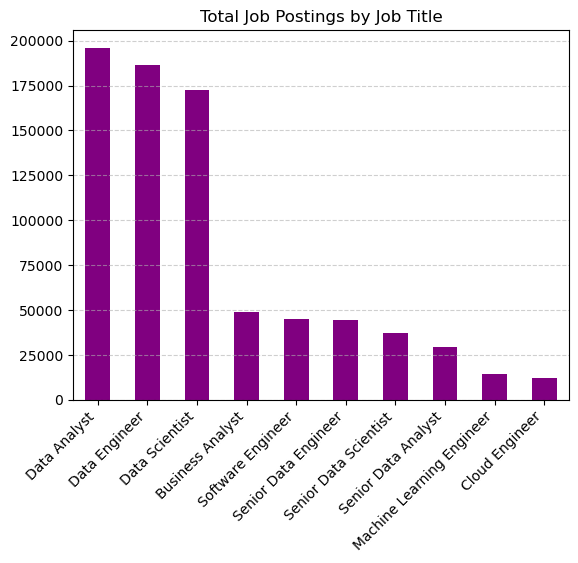

In [ ]:
# plotting only one plot, but utilizing fig and ax

fig, ax = plt.subplots()
df["job_title_short"].value_counts().plot(kind="bar", ax=ax, color="purple")
plt.title("Total Job Postings by Job Title")
plt.xlabel("")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.xticks(rotation=45, ha="right")
plt.show()

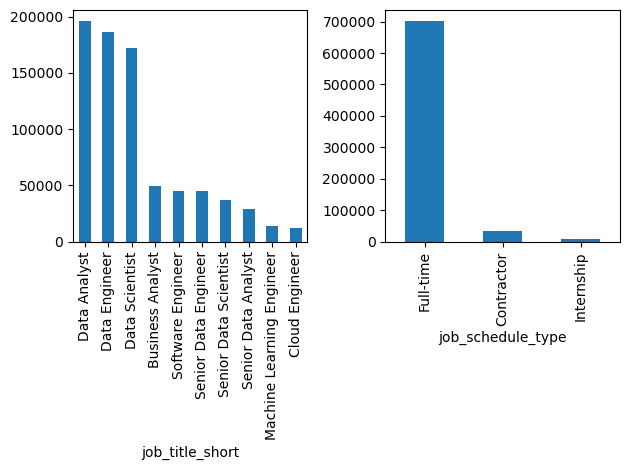

In [ ]:
# plotting two different plots utilizing the suplots function

fig, ax = plt.subplots(ncols=2) # create plot and define the axis (individual plots)

df["job_title_short"].value_counts().plot(kind="bar", ax=ax[0]) # define data of plot 1
df["job_schedule_type"].value_counts().head(3).plot(kind="bar", ax=ax[1]) # define data of plot 2

fig.tight_layout() # method that fits both plots into the figure without overlap

## Exercise: plot the top 5 skills for Data Scientists, Data Engineers and Data Analysts 

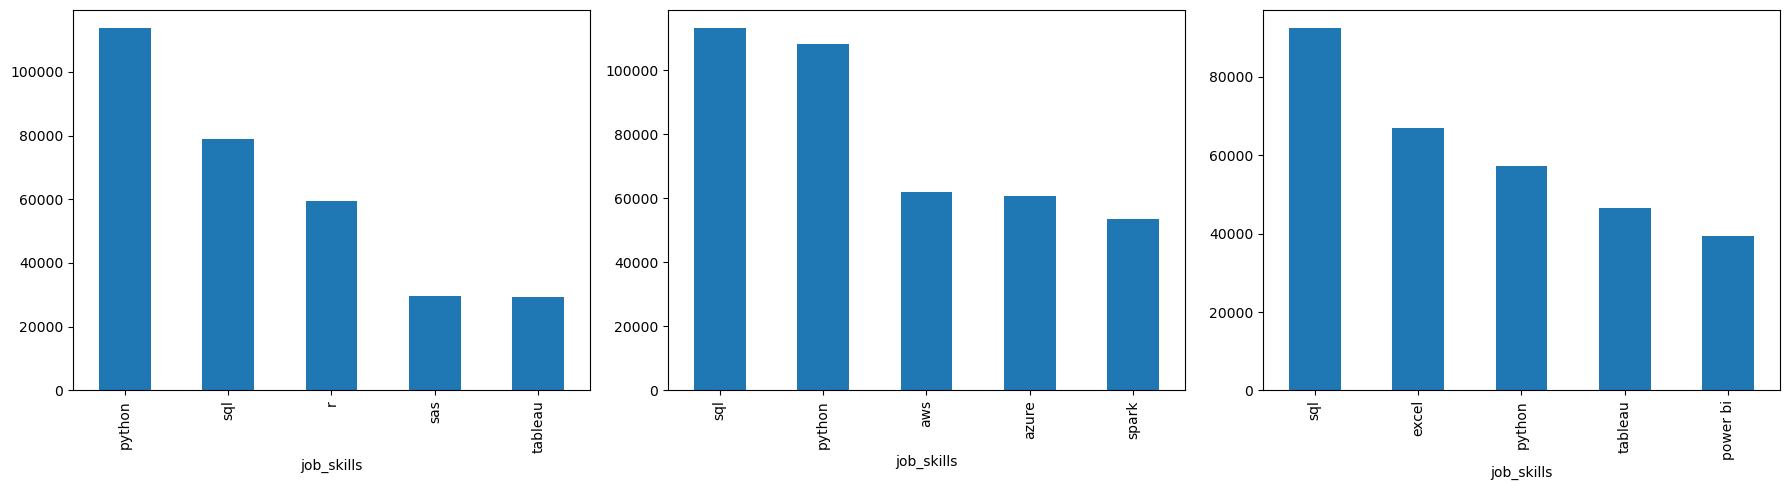

In [92]:
"""
My Solution
"""

# filtering data to create three different plots, calculating the top skills for data scientists, data engineers and data analysts

# create plot and axes
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))

# filter data to have only data scientists skills
df_scientist = df.loc[
    (df["job_skills"].notna()) & (df["job_title_short"] == "Data Scientist"),
    "job_skills"
].copy()

(
    df_scientist
        .explode()
        .value_counts()
        .head()
        .plot(kind="bar", ax=ax[0])
)

# filter data to have only data engineers skills
df_engineer = df.loc[
    (df["job_skills"].notna()) & (df["job_title_short"] == "Data Engineer"),
    "job_skills"
].copy()

(
    df_engineer
        .explode()
        .value_counts()
        .head()
        .plot(kind="bar", ax=ax[1])
)

# filter data to have only data analyst skills
df_analyst = df.loc[
    (df["job_skills"].notna()) & (df["job_title_short"] == "Data Analyst"),
    "job_skills"
].copy()

(
    df_analyst
        .explode()
        .value_counts()
        .head()
        .plot(kind="bar", ax=ax[2])
)

plt.tight_layout()

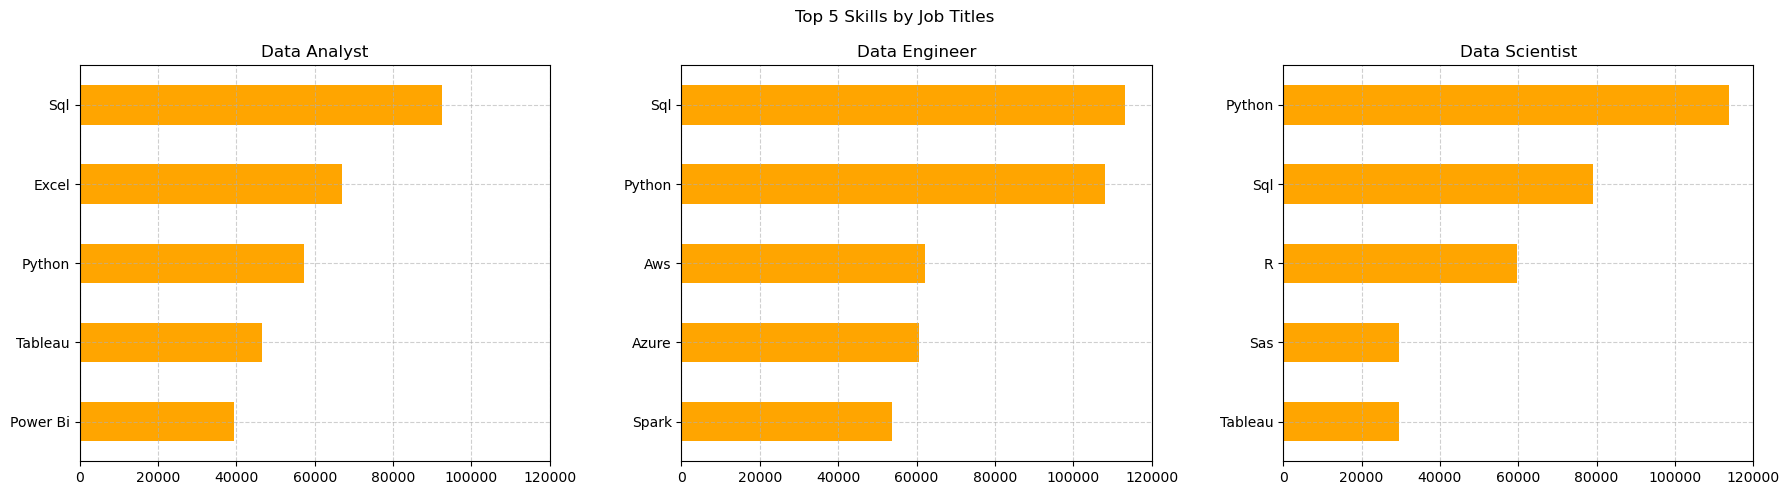

In [107]:
"""
Course solution
"""

# organize the data for plotting
df_skills = df.copy()
df_skills = df_skills.explode("job_skills")
skills_count = df_skills.groupby(["job_skills", "job_title_short"]).agg(
    skill_count=("job_skills", "size")
).reset_index()
skills_count.sort_values(by="skill_count", ascending=False, inplace=True)
skills_count["job_skills"] = skills_count["job_skills"].str.title()


# create list with the job titles that need to be analyzed
job_list = ["Data Analyst", "Data Engineer", "Data Scientist"]

# create plots
fig, ax = plt.subplots(ncols=3, figsize=(18, 5))

for i, job_title in enumerate(job_list):
    
    (
        skills_count.loc[
            skills_count["job_title_short"] == job_title,
            ["job_skills", "skill_count"]
        ]
        .sort_values(by="skill_count")
        .tail()
        .plot(kind="barh", x="job_skills", y="skill_count", ax=ax[i], legend=False, color="orange")
    )

    # plot cutomization
    ax[i].set_title(job_title)
    ax[i].grid(True, alpha=0.6, linestyle="--")
    ax[i].set_ylabel("")
    ax[i].set_xlim(0, 120_000)

fig.suptitle("Top 5 Skills by Job Titles")
fig.tight_layout(w_pad=3)
plt.show()


In [101]:
skills_count.loc[
    skills_count["job_title_short"] == "Data Analyst",
    ["job_skills", "skill_count"]
].sort_values(by="skill_count", ascending=False).head()

,job_skills,skill_count
1821,sql,92428
558,excel,66860
1478,python,57190
1941,tableau,46455
1410,power bi,39380


In [ ]:
skills_count

job_skills  job_title_short            skill_count
python      Data Scientist             113711         1
sql         Data Engineer              113130         1
python      Data Engineer              108022         1
sql         Data Analyst               92428          1
            Data Scientist             78982          1
                                                     ..
webex       Senior Data Scientist      1              1
codecommit  Business Analyst           1              1
xamarin     Machine Learning Engineer  1              1
mlr         Machine Learning Engineer  1              1
monday.com  Machine Learning Engineer  1              1
Name: count, Length: 2256, dtype: int64